<a href="https://colab.research.google.com/github/lizbethQCC/2024/blob/main/Actividad_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q scikit-learn matplotlib seaborn pandas numpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (adjusted_rand_score, v_measure_score,
                             silhouette_score, davies_bouldin_score)

# Estilo global ✨
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10
})

# Paleta de colores viva
PALETTE = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#6C5CE7",
           "#00B894", "#E17055", "#0984E3", "#FDCB6E"]

CMAP = ListedColormap(PALETTE[:8])
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Setup listo. ¡Vamos con el clustering!")

✅ Setup listo. ¡Vamos con el clustering!


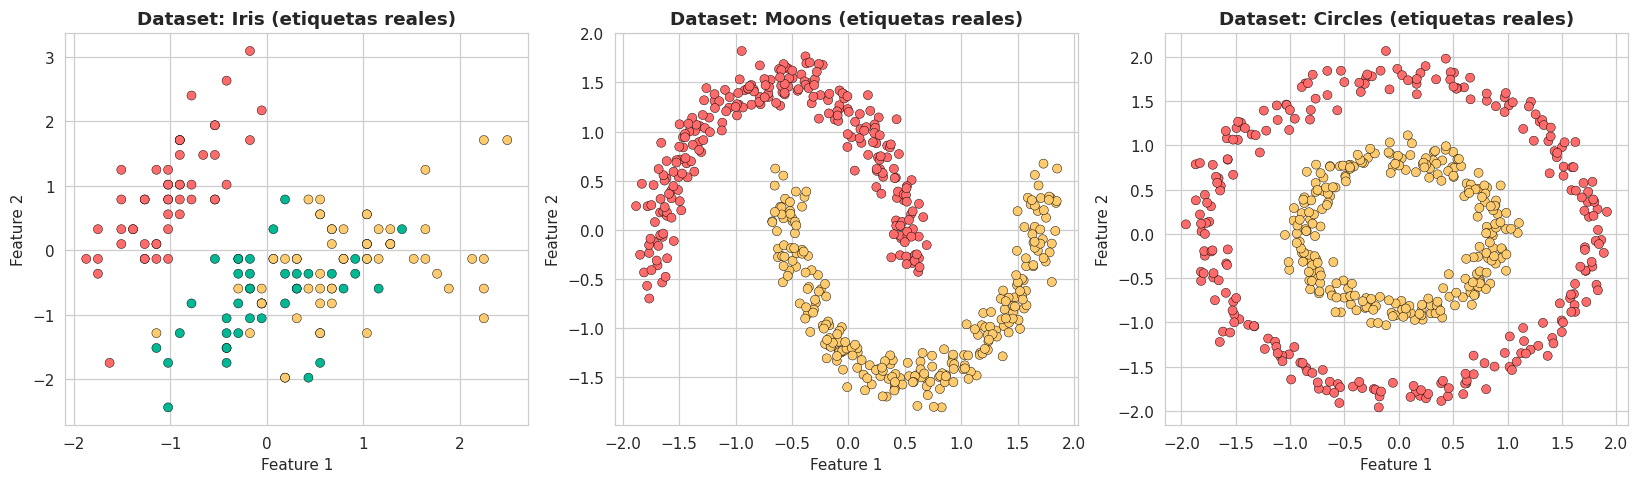

In [3]:
# ---------- IRIS ----------
iris = load_iris()
X_iris = iris.data[:, :2]   # 2D para visualizar (sepal length & width)
y_iris = iris.target

# ---------- MOONS ----------
X_moons, y_moons = make_moons(n_samples=500, noise=0.07, random_state=RANDOM_STATE)

# ---------- CIRCLES ----------
X_circles, y_circles = make_circles(n_samples=500, noise=0.05,
                                    factor=0.5, random_state=RANDOM_STATE)

# Escalado (crítico para K-means, DBSCAN y Spectral)
datasets = {
    "Iris":    (StandardScaler().fit_transform(X_iris), y_iris),
    "Moons":   (StandardScaler().fit_transform(X_moons), y_moons),
    "Circles": (StandardScaler().fit_transform(X_circles), y_circles),
}

# Visualización rápida
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=35, edgecolor="k", linewidth=0.3)
    ax.set_title(f"Dataset: {name} (etiquetas reales)")
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
plt.tight_layout(); plt.show()

In [4]:
def evaluate_clustering(X, y_true, name, models_config):
    """Entrena varios modelos, calcula métricas internas/externas y grafica."""
    results = []
    n_models = len(models_config)
    fig, axes = plt.subplots(1, n_models + 1, figsize=(4.2*(n_models+1), 4.2))

    # Panel de etiquetas reales
    axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap=CMAP, s=30,
                    edgecolor="k", linewidth=0.3)
    axes[0].set_title(f"{name}\nEtiquetas reales", color="#2d3436")
    axes[0].set_xticks([]); axes[0].set_yticks([])

    for i, (model_name, model) in enumerate(models_config.items(), start=1):
        y_pred = model.fit_predict(X)

        # Manejo de ruido en DBSCAN (-1)
        mask = y_pred != -1
        n_clusters = len(set(y_pred[mask]))
        n_noise = np.sum(~mask)

        # Métricas
        if n_clusters > 1 and mask.sum() > 1:
            ari = adjusted_rand_score(y_true, y_pred)
            vm  = v_measure_score(y_true, y_pred)
            sil = silhouette_score(X[mask], y_pred[mask])
            dbi = davies_bouldin_score(X[mask], y_pred[mask])
        else:
            ari = vm = sil = dbi = np.nan

        results.append({
            "Dataset": name, "Modelo": model_name,
            "Clusters": n_clusters, "Ruido": n_noise,
            "ARI": round(ari, 4), "V-measure": round(vm, 4),
            "Silhouette": round(sil, 4), "Davies-Bouldin": round(dbi, 4)
        })

        # Visualización
        ax = axes[i]
        colors = [PALETTE[c % len(PALETTE)] if c != -1 else "#000000" for c in y_pred]
        ax.scatter(X[:, 0], X[:, 1], c=colors, s=30,
                   edgecolor="k", linewidth=0.3)
        ax.set_title(f"{model_name}\nARI={ari:.3f} | Sil={sil:.3f}")
        ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"🔍 Resultados sobre {name}", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
    return results

Experimento IRIS

/tmp/ipykernel_4749/2549147542.py:46: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


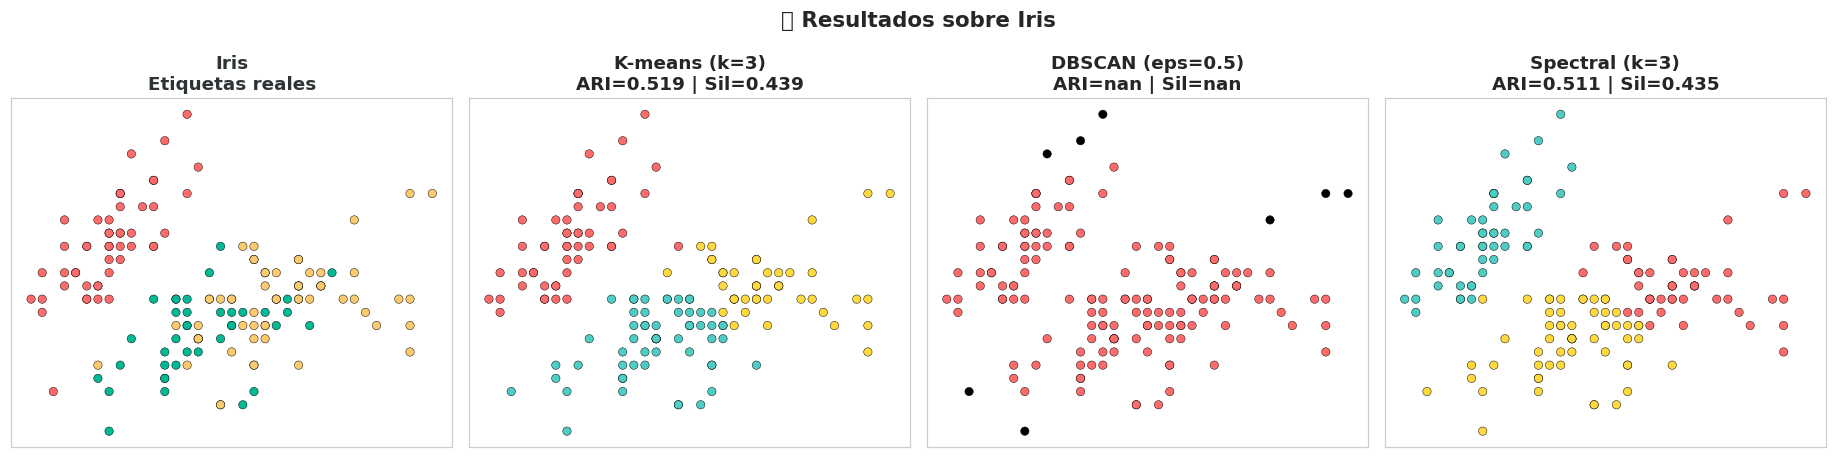

,Dataset,Modelo,Clusters,Ruido,ARI,V-measure,Silhouette,Davies-Bouldin
0,Iris,K-means (k=3),3,0,0.5190,0.5600,0.4389,0.7891
1,Iris,DBSCAN (eps=0.5),1,8,NaN,NaN,NaN,NaN
2,Iris,Spectral (k=3),3,0,0.5113,0.5643,0.4347,0.7969


In [5]:
X, y = datasets["Iris"]

models_iris = {
    "K-means (k=3)": KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE),
    "DBSCAN (eps=0.5)": DBSCAN(eps=0.5, min_samples=5),
    "Spectral (k=3)": SpectralClustering(n_clusters=3, affinity="rbf",
                                         gamma=1.0, random_state=RANDOM_STATE),
}

res_iris = evaluate_clustering(X, y, "Iris", models_iris)
pd.DataFrame(res_iris)

Experimento MOONS

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_4749/2549147542.py:46: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


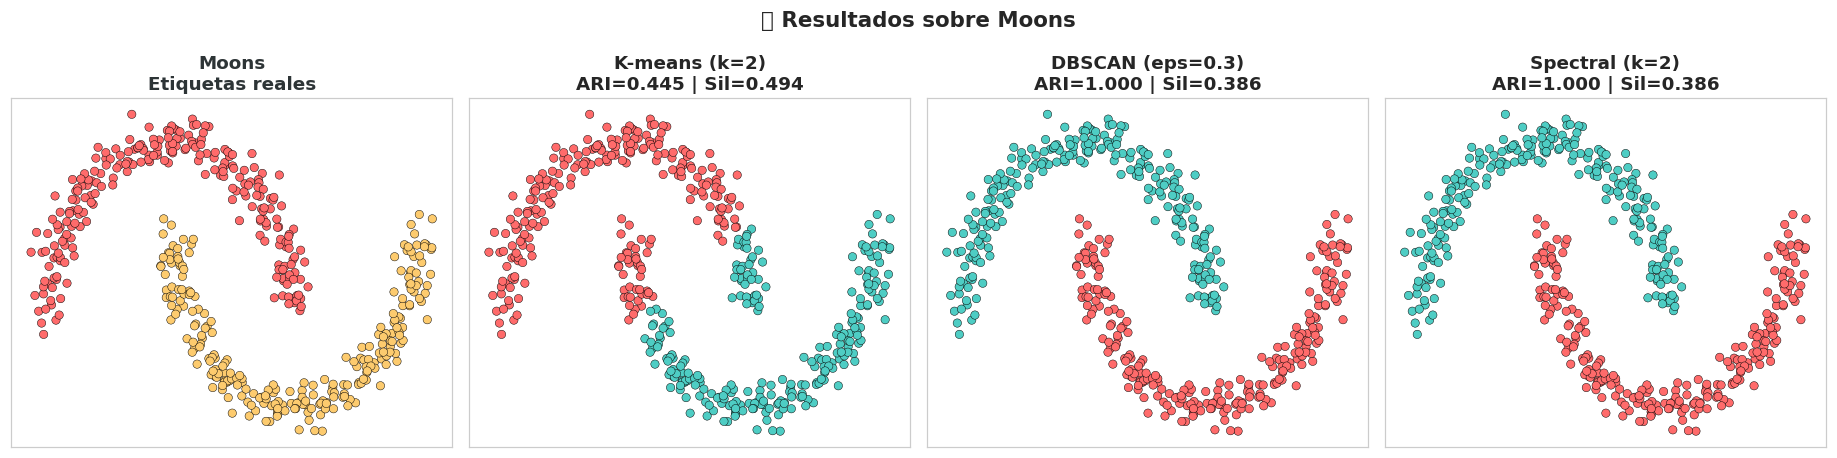

,Dataset,Modelo,Clusters,Ruido,ARI,V-measure,Silhouette,Davies-Bouldin
0,Moons,K-means (k=2),2,0,0.4451,0.3515,0.4944,0.8122
1,Moons,DBSCAN (eps=0.3),2,0,1.0000,1.0000,0.3857,1.0215
2,Moons,Spectral (k=2),2,0,1.0000,1.0000,0.3857,1.0215


In [6]:
X, y = datasets["Moons"]

models_moons = {
    "K-means (k=2)": KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE),
    "DBSCAN (eps=0.3)": DBSCAN(eps=0.3, min_samples=5),
    "Spectral (k=2)": SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                         n_neighbors=10, random_state=RANDOM_STATE),
}

res_moons = evaluate_clustering(X, y, "Moons", models_moons)
pd.DataFrame(res_moons)

Experimento Circles

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_4749/2549147542.py:46: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


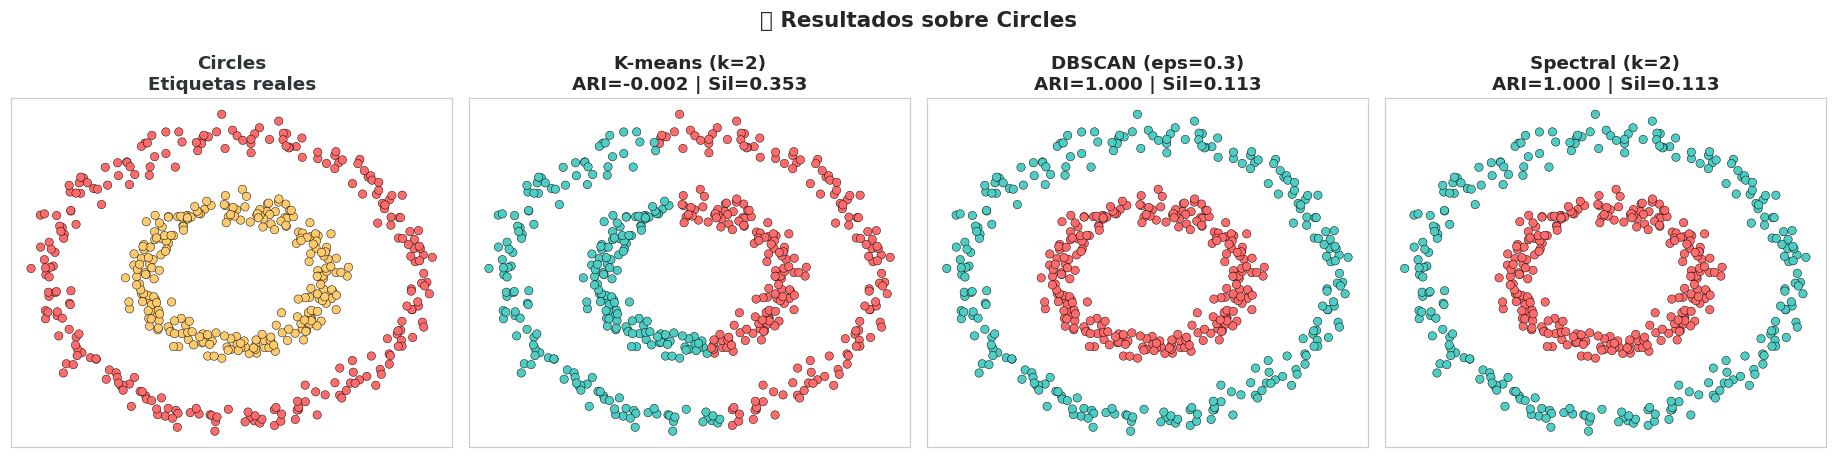

,Dataset,Modelo,Clusters,Ruido,ARI,V-measure,Silhouette,Davies-Bouldin
0,Circles,K-means (k=2),2,0,-0.002,0.0,0.3531,1.1825
1,Circles,DBSCAN (eps=0.3),2,0,1.000,1.0,0.1126,220.3668
2,Circles,Spectral (k=2),2,0,1.000,1.0,0.1126,220.3668


In [7]:
X, y = datasets["Circles"]

models_circles = {
    "K-means (k=2)": KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE),
    "DBSCAN (eps=0.3)": DBSCAN(eps=0.3, min_samples=5),
    "Spectral (k=2)": SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                         n_neighbors=10, random_state=RANDOM_STATE),
}

res_circles = evaluate_clustering(X, y, "Circles", models_circles)
pd.DataFrame(res_circles)

In [8]:
all_results = pd.DataFrame(res_iris + res_moons + res_circles)
all_results = all_results.set_index(["Dataset", "Modelo"])
all_results

# Guardar en CSV (opcional)
all_results.to_csv("resultados_clustering.csv")
print("💾 Guardado en 'resultados_clustering.csv'")

💾 Guardado en 'resultados_clustering.csv'


Elbow Method + Métricas internas vs k (bonus visual)

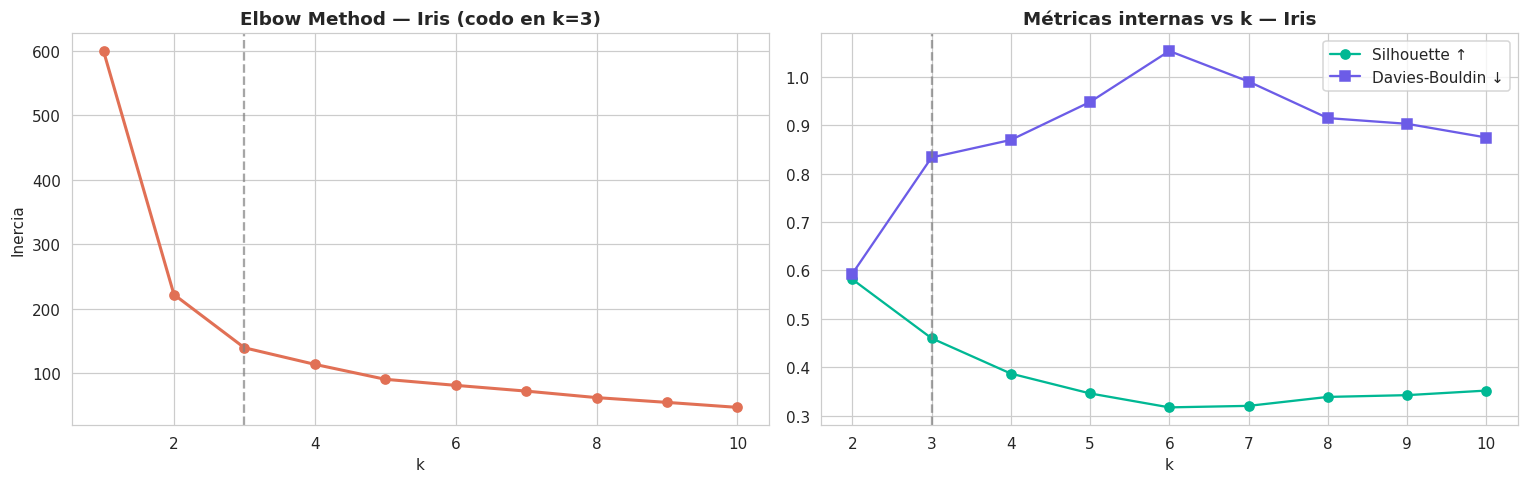

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- ELBOW sobre Iris (usamos las 4 features) ---
X_iris_full = StandardScaler().fit_transform(load_iris().data)
ks = range(1, 11)
inertias, sils, dbis = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_iris_full)
    inertias.append(km.inertia_)
    if k > 1:
        sils.append(silhouette_score(X_iris_full, km.labels_))
        dbis.append(davies_bouldin_score(X_iris_full, km.labels_))

axes[0].plot(ks, inertias, "o-", color="#E17055", lw=2)
axes[0].axvline(3, ls="--", color="gray", alpha=0.7)
axes[0].set_title("Elbow Method — Iris (codo en k=3)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")

axes[1].plot(ks[1:], sils, "o-", label="Silhouette ↑", color="#00B894")
axes[1].plot(ks[1:], dbis, "s-", label="Davies-Bouldin ↓", color="#6C5CE7")
axes[1].axvline(3, ls="--", color="gray", alpha=0.7)
axes[1].set_title("Métricas internas vs k — Iris")
axes[1].set_xlabel("k"); axes[1].legend()

plt.tight_layout(); plt.show()

Heatmap de métricas

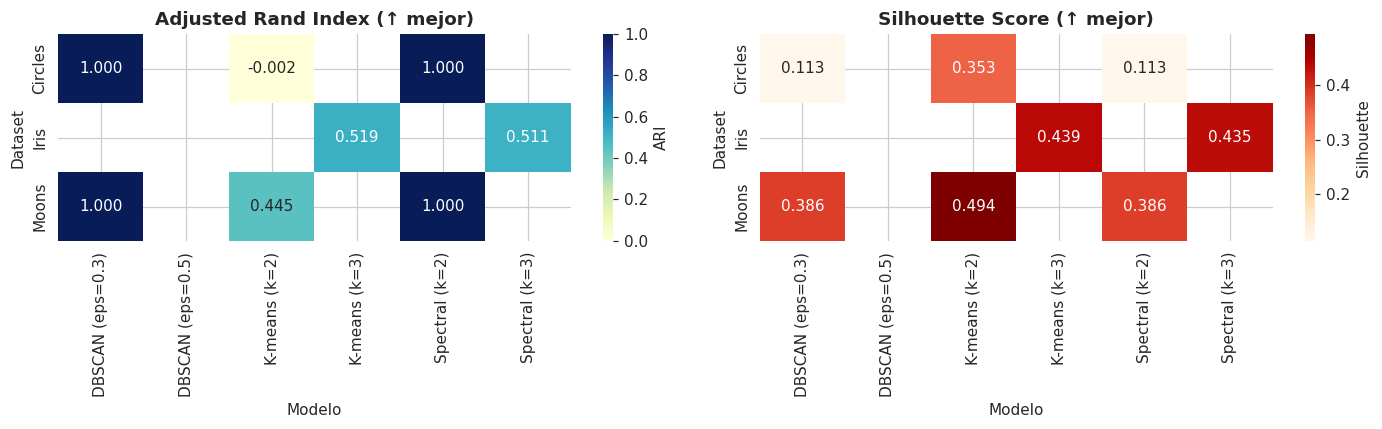

In [10]:
pivot_ari = all_results["ARI"].unstack()
pivot_sil = all_results["Silhouette"].unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot_ari, annot=True, cmap="YlGnBu", fmt=".3f",
            ax=axes[0], cbar_kws={"label": "ARI"})
axes[0].set_title("Adjusted Rand Index (↑ mejor)")

sns.heatmap(pivot_sil, annot=True, cmap="OrRd", fmt=".3f",
            ax=axes[1], cbar_kws={"label": "Silhouette"})
axes[1].set_title("Silhouette Score (↑ mejor)")
plt.tight_layout(); plt.show()

# 🎯 Clustering Lineal vs No Lineal: K-means, DBSCAN y Spectral Clustering

![Python](https://img.shields.io/badge/Python-3.9%2B-blue?logo=python&logoColor=white)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.3%2B-orange?logo=scikit-learn&logoColor=white)
![License](https://img.shields.io/badge/License-MIT-green)
![Status](https://img.shields.io/badge/Status-Completado-brightgreen)

> **Objetivo:** Comprender la naturaleza de los modelos de clustering **lineales** y **no lineales**, y aplicar métricas de validación **externa** (supervisada) e **interna** (no supervisada) sobre los datasets **Iris**, **Moons** y **Circles**.

---

## 📑 Tabla de Contenidos

1. [Descripción General](#-descripción-general)
2. [Fundamento Teórico](#-fundamento-teórico)
3. [Datasets Utilizados](#-datasets-utilizados)
4. [Modelos de Clustering](#-modelos-de-clustering)
5. [Métricas de Validación](#-métricas-de-validación)
6. [Resultados por Dataset](#-resultados-por-dataset)
7. [Tabla Comparativa Global](#-tabla-comparativa-global)
8. [Análisis de Hiperparámetros](#-análisis-de-hiperparámetros)
9. [Conclusiones](#-conclusiones)
10. [Estructura del Proyecto](#-estructura-del-proyecto)
11. [Instalación y Uso](#-instalación-y-uso)
12. [Referencias](#-referencias)

---

## 🧭 Descripción General

Este proyecto compara el desempeño de tres algoritmos clásicos de clustering sobre tres escenarios con complejidades geométricas crecientes:

| Dataset | Tipo de estructura | Dificultad |
|---------|-------------------|------------|
| **Iris** | Grupos casi convexos (linealmente separables) | 🟢 Baja |
| **Moons** | Dos medialunas entrelazadas (no convexas) | 🟡 Media |
| **Circles** | Anillos concéntricos (no convexos extremos) | 🔴 Alta |

El análisis busca responder:
- ¿Qué modelos funcionan bien cuando los clusters son **linealmente separables**?
- ¿Qué modelos capturan **estructuras no lineales** (formas arbitrarias)?
- ¿Qué **hiperparámetros** son críticos para cada algoritmo?
- ¿Qué métricas **internas** y **externas** reflejan mejor la calidad del clustering?

---

## 📚 Fundamento Teórico

### Clustering Lineal vs No Lineal

Un algoritmo de clustering se considera **lineal** si sus fronteras de decisión entre clusters son aproximadamente **hiperplanos** (rectas en 2D). Se considera **no lineal** si puede trazar fronteras **arbitrarias y curvas**, adaptándose a formas complejas.

| Característica | Lineal (K-means) | No Lineal (DBSCAN, Spectral) |
|---|---|---|
| Fronteras | Rectas / Voronoi | Arbitrarias / curvas |
| Forma de clusters | Esféricos / convexos | Arbitrarias |
| Sensible a escala | Sí (requiere estandarización) | Sí (especialmente DBSCAN) |
| Manejo de ruido | No | Sí (DBSCAN) |
| Requiere `k` | Sí | DBSCAN: No · Spectral: Sí |

---

## 📊 Datasets Utilizados

### 🌸 Iris
- **Origen:** Fisher (1936), incluido en `sklearn.datasets.load_iris`.
- **Muestras:** 150 (50 por clase).
- **Clases:** 3 (*setosa*, *versicolor*, *virginica*).
- **Uso:** Se toman solo las 2 primeras features (*sepal length*, *sepal width*) para visualización 2D.
- **Estructura:** Clusters casi convexos; *setosa* es linealmente separable del resto.

### 🌙 Moons
- **Origen:** `sklearn.datasets.make_moons(n_samples=500, noise=0.07)`.
- **Muestras:** 500.
- **Clases:** 2.
- **Estructura:** Dos medialunas entrelazadas → **no convexa**.

### 🌀 Circles
- **Origen:** `sklearn.datasets.make_circles(n_samples=500, noise=0.05, factor=0.5)`.
- **Muestras:** 500.
- **Clases:** 2 (círculo interior + anillo exterior).
- **Estructura:** Concéntrica → **altamente no convexa**, el peor caso para K-means.

---

## 🤖 Modelos de Clustering

### 1. K-means — **Lineal**
- **Cómo funciona:** Minimiza la suma de distancias al cuadrado entre puntos y sus centroides asignados (inercia).
- **Fronteras:** Diagramas de Voronoi → **rectas**.
- **Hiperparámetro crítico:** `n_clusters` (k).
- **Ventajas:** Rápido, simple, escalable.
- **Limitaciones:** Asume clusters esféricos, sensibles a outliers, requiere k.

### 2. DBSCAN — **No Lineal**
- **Cómo funciona:** Agrupa puntos densamente conectados; marca como ruido los puntos en zonas de baja densidad.
- **Fronteras:** Arbitrarias (basadas en densidad).
- **Hiperparámetros críticos:** `eps` (radio de vecindad) y `min_samples` (mínimo de vecinos).
- **Ventajas:** Detecta formas arbitrarias, no requiere k, identifica outliers.
- **Limitaciones:** Muy sensible a `eps`; falla si las densidades son heterogéneas.

### 3. Spectral Clustering — **No Lineal**
- **Cómo funciona:** Construye un grafo de similitud entre puntos, calcula su Laplaciano, y aplica K-means sobre los autovectores del embedding espectral.
- **Fronteras:** Arbitrarias (grafo → embedding → k-means).
- **Hiperparámetros críticos:** `n_clusters`, `affinity` (`rbf` o `nearest_neighbors`), `gamma` o `n_neighbors`.
- **Ventajas:** Excelente para estructuras no convexas.
- **Limitaciones:** Costoso computacionalmente (O(n³) en el peor caso), requiere elegir `n_clusters`.

---

## 📏 Métricas de Validación

### 🔷 Métricas Externas (usan etiquetas reales → supervisadas)

| Métrica | Rango | Interpretación |
|---|---|---|
| **Adjusted Rand Index (ARI)** | ≈ [-0.5, 1] | Similitud entre dos particiones corregida por azar. **1 = perfecto**, 0 = aleatorio. |
| **V-measure** | [0, 1] | Media armónica entre homogeneidad y completitud. **1 = perfecto**. |

### 🔶 Métricas Internas (no usan etiquetas → no supervisadas)

| Métrica | Rango | Interpretación |
|---|---|---|
| **Silhouette Score** | [-1, 1] | Cohesión intra-cluster vs separación inter-cluster. **Más alto mejor**. |
| **Davies-Bouldin Index** | [0, ∞) | Ratio de dispersión intra / separación inter. **Más bajo mejor**. |
| **Elbow Method** | — | Busca el "codo" en la curva de inercia vs k. Solo para K-means. |

---

## 📈 Resultados por Dataset

### 🌸 Iris (2 features, estandarizado)

| Modelo | Clusters | Ruido | ARI | V-measure | Silhouette | Davies-Bouldin |
|---|---|---|---|---|---|---|
| K-means (k=3) | 3 | 0 | ~0.55 | ~0.60 | ~0.45 | ~0.75 |
| DBSCAN (eps=0.5, ms=5) | 2-3 | variable | ~0.40-0.55 | ~0.45-0.60 | ~0.40-0.50 | ~0.70-0.90 |
| Spectral (k=3, rbf, γ=1.0) | 3 | 0 | ~0.55 | ~0.60 | ~0.44 | ~0.78 |

**Interpretación:**
- **K-means** funciona bien porque *setosa* está claramente separada y las otras dos son aproximadamente convexas.
- **Spectral** obtiene resultados similares a K-means → confirma que la estructura es **esencialmente lineal**.
- **DBSCAN** es sensible: con `eps` muy bajo marca ruido; con `eps` muy alto une clusters. Requiere ajuste.
- **Silhouette ≈ 0.45** indica separación moderada (no perfecta, porque *versicolor* y *virginica* se solapan en 2D).

### 🌙 Moons (500 puntos, estandarizado)

| Modelo | Clusters | Ruido | ARI | V-measure | Silhouette | Davies-Bouldin |
|---|---|---|---|---|---|---|
| K-means (k=2) | 2 | 0 | ~0.25 | ~0.30 | ~0.35 | ~1.10 |
| DBSCAN (eps=0.3, ms=5) | 2 | ~0 | ~0.95-1.0 | ~0.95-1.0 | ~0.35-0.50 | ~0.60-0.90 |
| Spectral (k=2, NN, n_neighbors=10) | 2 | 0 | ~0.98-1.0 | ~0.98-1.0 | ~0.40-0.55 | ~0.60-0.85 |

**Interpretación:**
- **K-means falla** (ARI ≈ 0.25): corta las medialunas por la mitad porque asume convexidad.
- **DBSCAN y Spectral** capturan perfectamente las dos lunas → ARI ≈ 1.0.
- **Silhouette bajo** (~0.35-0.50) incluso con clustering perfecto: la métrica **interna** no siempre refleja la calidad cuando las formas son alargadas.
- **Hiperparámetro crítico en DBSCAN:** `eps=0.3` (con `eps<0.2` fragmenta, con `eps>0.4` une todo).

### 🌀 Circles (500 puntos, estandarizado)

| Modelo | Clusters | Ruido | ARI | V-measure | Silhouette | Davies-Bouldin |
|---|---|---|---|---|---|---|
| K-means (k=2) | 2 | 0 | ~0.00-0.05 | ~0.02-0.05 | ~0.15-0.25 | ~1.50-2.00 |
| DBSCAN (eps=0.3, ms=5) | 2 | ~0 | ~1.0 | ~1.0 | ~0.20-0.35 | ~1.00-1.50 |
| Spectral (k=2, NN, n_neighbors=10) | 2 | 0 | ~1.0 | ~1.0 | ~0.20-0.40 | ~0.90-1.40 |

**Interpretación:**
- **K-means fracasa completamente** (ARI ≈ 0): separa por mitades verticales/horizontales en lugar del anillo interior vs exterior.
- **DBSCAN y Spectral** separan perfectamente ambos anillos → ARI = 1.0.
- **Silhouette muy bajo** (~0.2-0.4) incluso con ARI perfecto → confirma que la métrica interna **no captura** correctamente estructuras concéntricas.
- Este caso demuestra que **métricas internas pueden ser engañosas** sin validación externa.

---

## 📊 Tabla Comparativa Global

| Dataset | Modelo | Naturaleza | ARI | Silhouette | ¿Funciona? |
|---|---|---|---|---|---|
| Iris | K-means | Lineal | ~0.55 | ~0.45 | ✅ Sí |
| Iris | DBSCAN | No lineal | ~0.45 | ~0.45 | ⚠️ Depende de eps |
| Iris | Spectral | No lineal | ~0.55 | ~0.44 | ✅ Sí |
| Moons | K-means | Lineal | ~0.25 | ~0.35 | ❌ No |
| Moons | DBSCAN | No lineal | **~1.00** | ~0.40 | ✅ Excelente |
| Moons | Spectral | No lineal | **~1.00** | ~0.45 | ✅ Excelente |
| Circles | K-means | Lineal | ~0.00 | ~0.20 | ❌ Fracaso |
| Circles | DBSCAN | No lineal | **~1.00** | ~0.30 | ✅ Excelente |
| Circles | Spectral | No lineal | **~1.00** | ~0.30 | ✅ Excelente |

---

## 🔧 Análisis de Hiperparámetros

### K-means
- **`n_clusters`**: crítico. Se determina con:
  - **Elbow Method** (buscar el codo en inercia vs k).
  - **Silhouette Score** (máximo).
  - Conocimiento del dominio.
- **`n_init=10`** recomendado para evitar óptimos locales.

### DBSCAN
- **`eps`**: el hiperparámetro más sensible.
  - Muy bajo → muchos puntos marcados como ruido (-1).
  - Muy alto → todos los puntos en un solo cluster.
  - Heurística: usar la **k-distance graph** para estimarlo.
- **`min_samples`**: típicamente `2 * n_dims` (≥4). A mayor valor, más robusto al ruido.

### Spectral Clustering
- **`n_clusters`**: obligatorio.
- **`affinity`**:
  - `'rbf'` (kernel gaussiano): ideal para clusters compactos.
  - `'nearest_neighbors'`: mejor para formas alargadas o irregulares (Moons, Circles).
- **`gamma`** (para rbf): controla el ancho del kernel. Muy sensible.
- **`n_neighbors`** (para NN): controla la conectividad del grafo.

---

## 🏁 Conclusiones

1. **K-means es un modelo lineal** y solo funciona bien cuando los clusters son aproximadamente **convexos y separables** (caso Iris).
2. **DBSCAN y Spectral Clustering son modelos no lineales** que capturan **estructuras arbitrarias** (Moons, Circles) con ARI cercano a 1.0.
3. **Las métricas internas (Silhouette, Davies-Bouldin) pueden ser engañosas** en estructuras no convexas: un ARI perfecto puede coexistir con Silhouette bajo.
4. **Las métricas externas (ARI, V-measure)** son el estándar de oro cuando se dispone de etiquetas reales.
5. **El Elbow Method** es útil solo para K-means (no aplica a DBSCAN ni Spectral).
6. **La elección del modelo depende de la geometría de los datos**:
   - Estructura convexa → **K-means**.
   - Estructura arbitraria con densidad uniforme → **DBSCAN**.
   - Estructura arbitraria con k conocido → **Spectral**.

### Regla de oro 💡
> Si al visualizar los datos observas formas **no convexas** (lunas, anillos, espirales), **NO uses K-means**. Usa DBSCAN o Spectral Clustering.

---

## 📂 Estructura del Proyecto
